# Analysis over data preparation

After cleaning each dataset from undesired events and adding new engineered features, we mimik the analyses done in the data understanding phase.

Below are defined the functions later called for each dataset:
- `_load_dataset(*)` loads the `.root` files and returns a Pandas DataFrame;
- `_correlation_heatmap(*)` shows the Pearson correlation heatmap between continuous features only;
- `_scatterplot_MET(*)` shows the relationship between the features `MET_pt` and `GenMET_pt`;
- `_data_distributions(*)` shows the distributions via histograms of the continuous features;
- `_boxplots(*)` shows the boxplot for each continuous feature to indentify outliers;
- `_data_barplots(*)` shows the barplots for each descrete feature.
- `nJet_vs_nGenJet` shows the barplots for the reconstructed and generator level jet multiplicities side by side. This time is defined separately from the other barplots as the jet features are only present in the HToAATo2Mu2B dataset.

Finally, some features are dropped as they are not considered relevant for the downstream ML model.

In [39]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import uproot

In [40]:
DATASETS = {
    "ZZTo2L2Nu": {
        "path": "../CleanedDatasets/cleaned_ZZTo2L2Nu.root",
        "float_features": [
            "GenMET_pt", "MET_covXX", "MET_covXY", "MET_covYY",
            "MET_phi", "MET_pt", "MET_significance",
            "PV_x", "PV_y", "PV_z", "PV_chi2", "PV_score",
            "Electron_dxy_st", "Electron_dz_st", "Electron_eta_st",
            "Electron_mass_st", "Electron_phi_st", "Electron_pt_st",
            "Electron_dxy_nd", "Electron_dz_nd", "Electron_eta_nd",
            "Electron_mass_nd", "Electron_phi_nd", "Electron_pt_nd",
            "Muon_dxy_st", "Muon_dz_st", "Muon_eta_st",
            "Muon_mass_st", "Muon_phi_st", "Muon_pt_st",
            "Muon_dxy_nd", "Muon_dz_nd", "Muon_eta_nd",
            "Muon_mass_nd", "Muon_phi_nd", "Muon_pt_nd"
        ],
        "int_features": [
            "nElectron", "nMuon", "nSV",
            "Electron_charge_st", "Electron_charge_nd",
            "Muon_charge_st", "Muon_charge_nd"
        ]
    },
    "HToAATo2Mu2B": {
        "path": "../CleanedDatasets/cleaned_HToAATo2Mu2B.root",
        "float_features": [
            "GenMET_pt", "MET_covXX", "MET_covXY", "MET_covYY",
            "MET_phi", "MET_pt", "MET_significance", "fixedGridRhoFastjetAll",
            "PV_x", "PV_y", "PV_z", "PV_chi2", "PV_score",
            "Jet_eta_bst", "Jet_pt_bst", "Jet_phi_bst", "Jet_mass_bst",
            "Jet_area_bst", "Jet_btag_bst", "Jet_rawFactor_bst",
            "Jet_chHEF_bst", "Jet_neHEF_bst", "Jet_chEmEF_bst", "Jet_neEmEF_bst", "Jet_muEF_bst",
            "Jet_eta_bnd", "Jet_pt_bnd", "Jet_phi_bnd", "Jet_mass_bnd",
            "Jet_area_bnd", "Jet_btag_bnd", "Jet_rawFactor_bnd",
            "Jet_chHEF_bnd", "Jet_neHEF_bnd", "Jet_chEmEF_bnd", "Jet_neEmEF_bnd", "Jet_muEF_bnd",
            "Muon_dxy_st", "Muon_dz_st", "Muon_eta_st",
            "Muon_mass_st", "Muon_phi_st", "Muon_pt_st",
            "Muon_dxy_nd", "Muon_dz_nd", "Muon_eta_nd",
            "Muon_mass_nd", "Muon_phi_nd", "Muon_pt_nd",
            "SV_dlenSig_bst", "SV_mass_bst", "M_mumu", "M_bb", "M_mumu_bb",
            "dR_MET_bb", "MET_projection_par", "MET_projection_perp",
            "dPhi_MET_mu1", "dPhi_MET_jet1", "HT"
        ],
        "int_features": [
            "nJet", "nMuon", "nSV", "nGenJet",
            "Muon_charge_st", "Muon_charge_nd"
        ]
    }
}

TREE_NAME = "Events"

PALETTE = ["royalblue", "orangered"]

In [41]:
def _load_dataset(FLOAT_FEATURES, INT_FEATURES, path, tree_name):
    """
        Loads branches from a .root file and returns a Pandas DataFrame.
    """
    all_branches = FLOAT_FEATURES + INT_FEATURES
    with uproot.open(f"{path}:{tree_name}") as tree:
        df = tree.arrays(all_branches, library="pd")

    # Explicit casting
    df[FLOAT_FEATURES] = df[FLOAT_FEATURES].astype(np.float64)
    df[INT_FEATURES]   = df[INT_FEATURES].astype(np.int64)
    return df

In [42]:
def _correlation_heatmap(df, FLOAT_FEATURES, label):
    corr = df[FLOAT_FEATURES].replace([np.inf, -np.inf], np.nan).corr()

    print("\nCouples of features with correlation > 0.70:")
    high_corr = []
    for i in range(len(corr.columns)):
        for j in range(i):
            corr_value = corr.iloc[i, j]
            if abs(corr_value) > 0.70:
                feat1 = corr.columns[i]
                feat2 = corr.columns[j]
                high_corr.append((feat1, feat2, corr_value))
                print(f"{feat1}, {feat2} = {corr_value:.2f}")

    n = len(corr)

    fig_size  = max(14, n * 0.45)
    font_size = max(5, min(8, 250 // n))

    fig, ax = plt.subplots(figsize=(fig_size, fig_size * 0.9))
    sns.heatmap(
        corr,
        annot=True, fmt=".2f",
        cmap="coolwarm", linewidths=0.3, linecolor="gray",
        annot_kws={"size": font_size},
        ax=ax
    )
    ax.set_title(f"Correlation Heatmap — {label}", fontsize=12, fontweight="bold", pad=12)
    ax.tick_params(axis="x", rotation=45, labelsize=font_size+1)
    ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right', fontsize=font_size+1)
    ax.tick_params(axis="y", rotation=0,  labelsize=font_size+1)
    fig.tight_layout()
    plt.show()
    return

In [43]:
def _scatterplot_MET(df, label, color):
    x = df["MET_pt"]
    y = df["GenMET_pt"]
    mask = np.isfinite(x) & np.isfinite(y)

    # Statistics
    print(f"Statistics for dataset {label}:")
    print(f"    Mean MET_pt: {x.mean()}, Median MET_pt: {x.median()}")
    print(f"    Mean GenMET_pt: {y.mean()}, Median GenMET_pt: {y.median()}")

    plt.figure(figsize=(10, 8))
    plt.scatter(
        x[mask], y[mask], s=4, alpha=0.35,
        color=color, label=label, rasterized=True)

    # y = x line
    lim_max = plt.xlim()[1]
    lim = [0, lim_max]
    plt.plot(lim, lim, "k--", lw=1, label="y = x")

    plt.title(f"GenMET vs MET - {label}", fontsize=13, fontweight="bold")
    plt.xlabel("MET_pt [GeV]", fontsize=11)
    plt.ylabel("GenMET_pt [GeV]", fontsize=11)
    plt.legend(markerscale=3, fontsize=9)
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.plot()
    return

In [44]:
def _data_distributions(df, FLOAT_FEATURES, label, color):
    n_feat = len(FLOAT_FEATURES)
    ncols = 3
    nrows = (n_feat + ncols - 1) // ncols

    fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 4 * nrows))
    axes = axes.flatten()

    for idx, feat in enumerate(FLOAT_FEATURES):
        ax = axes[idx]
        vals = df[feat].replace([np.inf, -np.inf], np.nan).dropna()
        ax.hist(vals, bins=100, density=True, histtype="step",
                linewidth=1.5, color=color, label=label)
        ax.set_xlabel(feat, fontsize=9)
        ax.set_ylabel("Density", fontsize=8)
        ax.set_title(feat, fontsize=9, fontweight="bold")
        ax.legend(fontsize=7)
        ax.grid(alpha=0.25)

    for j in range(idx + 1, len(axes)):
        axes[j].set_visible(False)

    fig.suptitle(f"Distributions for float features - {label}", fontsize=14, fontweight="bold", y=1.01)
    fig.tight_layout()
    plt.show()
    return

In [45]:
def _boxplots(df, FLOAT_FEATURES, label, color):
    n_feat = len(FLOAT_FEATURES)
    ncols = 3
    nrows = (n_feat + ncols - 1) // ncols
    fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 4 * nrows))
    axes = axes.flatten()

    print(f"Outliers — {label}")

    for idx, feat in enumerate(FLOAT_FEATURES):
        ax = axes[idx]
        vals = df[feat].replace([np.inf, -np.inf], np.nan).dropna()

        # IQR
        q1, q3 = vals.quantile(0.25), vals.quantile(0.75)
        IQR = q3 - q1
        lower, upper = q1 - 1.5 * IQR, q3 + 1.5 * IQR
        n_outliers = ((vals < lower) | (vals > upper)).sum()
        pct = n_outliers / len(vals) * 100
        print(f"  {feat:<20} {n_outliers:>6} outliers ({pct:.2f}%)")

        bp = ax.boxplot(vals, patch_artist=True, vert=True,
                        flierprops=dict(marker=".", markersize=2, alpha=0.3,
                                        markerfacecolor=color, markeredgecolor=color),
                        medianprops=dict(color="black", linewidth=1.5),
                        boxprops=dict(facecolor=color, alpha=0.5),
                        whiskerprops=dict(color=color),
                        capprops=dict(color=color))

        ax.set_title(feat, fontsize=9, fontweight="bold")
        ax.set_ylabel(feat, fontsize=8)
        ax.set_xticks([])
        ax.text(0.97, 0.97, f"{n_outliers} outliers\n({pct:.1f}%)",
                transform=ax.transAxes, fontsize=7,
                verticalalignment="top", horizontalalignment="right",
                bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.7))
        ax.grid(axis="y", alpha=0.25)

    for j in range(idx + 1, len(axes)):
        axes[j].set_visible(False)

    fig.suptitle(f"Boxplots — {label}", fontsize=14, fontweight="bold", y=1.01)
    fig.tight_layout()
    plt.show()
    return

In [46]:
def _draw_bar(ax, df, feat, color, label):
    vals = df[feat].dropna()
    bins = np.arange(int(vals.min()), int(vals.max()) + 2) - 0.5
    centers = (bins[:-1] + bins[1:]) / 2
    counts, _ = np.histogram(vals, bins=bins)
    ax.bar(centers, counts, width=0.8, color=color, label=label, alpha=0.85)
    ax.set_xlabel(feat, fontsize=10)
    ax.set_ylabel("Counts", fontsize=10)
    ax.set_title(feat, fontsize=11, fontweight="bold")
    ax.legend(fontsize=8)
    ax.grid(axis="y", alpha=0.3)
    return

def _data_barplots(df, INT_FEATURES, label, color):
    n_feat = len(INT_FEATURES)
    ncols = 2
    nrows = (n_feat + ncols - 1) // ncols
    fig, axes = plt.subplots(nrows, ncols, figsize=(7 * ncols, 5 * nrows))
    axes = axes.flatten()

    for idx, feat in enumerate(INT_FEATURES):
        _draw_bar(axes[idx], df, feat, color, label)

    for j in range(idx + 1, len(axes)):
        axes[j].set_visible(False)

    fig.suptitle(f"Barplots for integer features — {label}", fontsize=14, fontweight="bold", y=1.01)
    fig.tight_layout()
    plt.show()
    return

In [47]:
def _nJet_vs_nGenJet(df, label, color):
    fig, ax = plt.subplots(figsize=(7, 5))

    all_jet = pd.concat([df["nJet"], df["nGenJet"]]).dropna()
    bins = np.arange(int(all_jet.min()), int(all_jet.max()) + 2) - 0.5
    centers = (bins[:-1] + bins[1:]) / 2
    width = 0.8 / 2

    for i, (feat, hatch, alpha) in enumerate([("nJet", "", 0.75), ("nGenJet", "//", 0.45)]):
        counts, _ = np.histogram(df[feat].dropna(), bins=bins)
        offset = (i - 1 + 0.5) * width
        ax.bar(centers + offset, counts, width=width * 0.9,
               color=color, alpha=alpha, hatch=hatch,
               edgecolor="grey", linewidth=0.4,
               label=f"{label} — {feat}")

    ax.set_xticks(np.arange(int(all_jet.min()), int(all_jet.max()) + 1))
    ax.set_xlabel("n", fontsize=10)
    ax.set_ylabel("Counts", fontsize=10)
    ax.set_title(f"nJet vs nGenJet — {label}", fontsize=11, fontweight="bold")
    ax.legend(fontsize=7, ncol=2)
    ax.grid(axis="y", alpha=0.3)
    fig.tight_layout()
    plt.show()
    return

---

## ZZTo2L2Nu Dataset

The dataset was filtered to retain only the two expected signal channels:
- the doble electron channel (2e + 0μ), where the Z decays into two electrons and two neutrinos;
- the double muon channel (0e + 2μ), where the Z decays into two muons and two neutrinos.

Non-physical events were also removed, including those with particles having negative invariant mass, negative transverse momentum, or events with negative Missing Transverse Energy.

In [48]:
label = "ZZTo2L2Nu"
entry = DATASETS[label]

FLOAT_FEATURES_ZZTo2L2Nu = entry["float_features"]
INT_FEATURES_ZZTo2L2Nu = entry["int_features"]
color = PALETTE[0]

df = _load_dataset(FLOAT_FEATURES_ZZTo2L2Nu, INT_FEATURES_ZZTo2L2Nu, entry["path"], TREE_NAME)
print(f"Dataset {label}:")
print(f"    {df.shape[1]} features x {df.shape[0]} events")
print(f"    Number of float features: {len(FLOAT_FEATURES_ZZTo2L2Nu)}")
print(f"    Number of int features:   {len(INT_FEATURES_ZZTo2L2Nu)}")

Dataset ZZTo2L2Nu:
    43 features x 30324 events
    Number of float features: 36
    Number of int features:   7



Couples of features with correlation > 0.70:
MET_covYY, MET_covXX = 0.91
MET_pt, GenMET_pt = 0.93
PV_score, MET_significance = 0.73
Electron_pt_st, Electron_mass_st = 0.77
Electron_pt_nd, Electron_pt_st = 0.81
Electron_pt_nd, Electron_mass_nd = 0.76
Muon_mass_st, Electron_pt_st = -0.82
Muon_mass_st, Electron_pt_nd = -0.83
Muon_mass_nd, Electron_pt_st = -0.82
Muon_mass_nd, Electron_pt_nd = -0.83
Muon_mass_nd, Muon_mass_st = 1.00


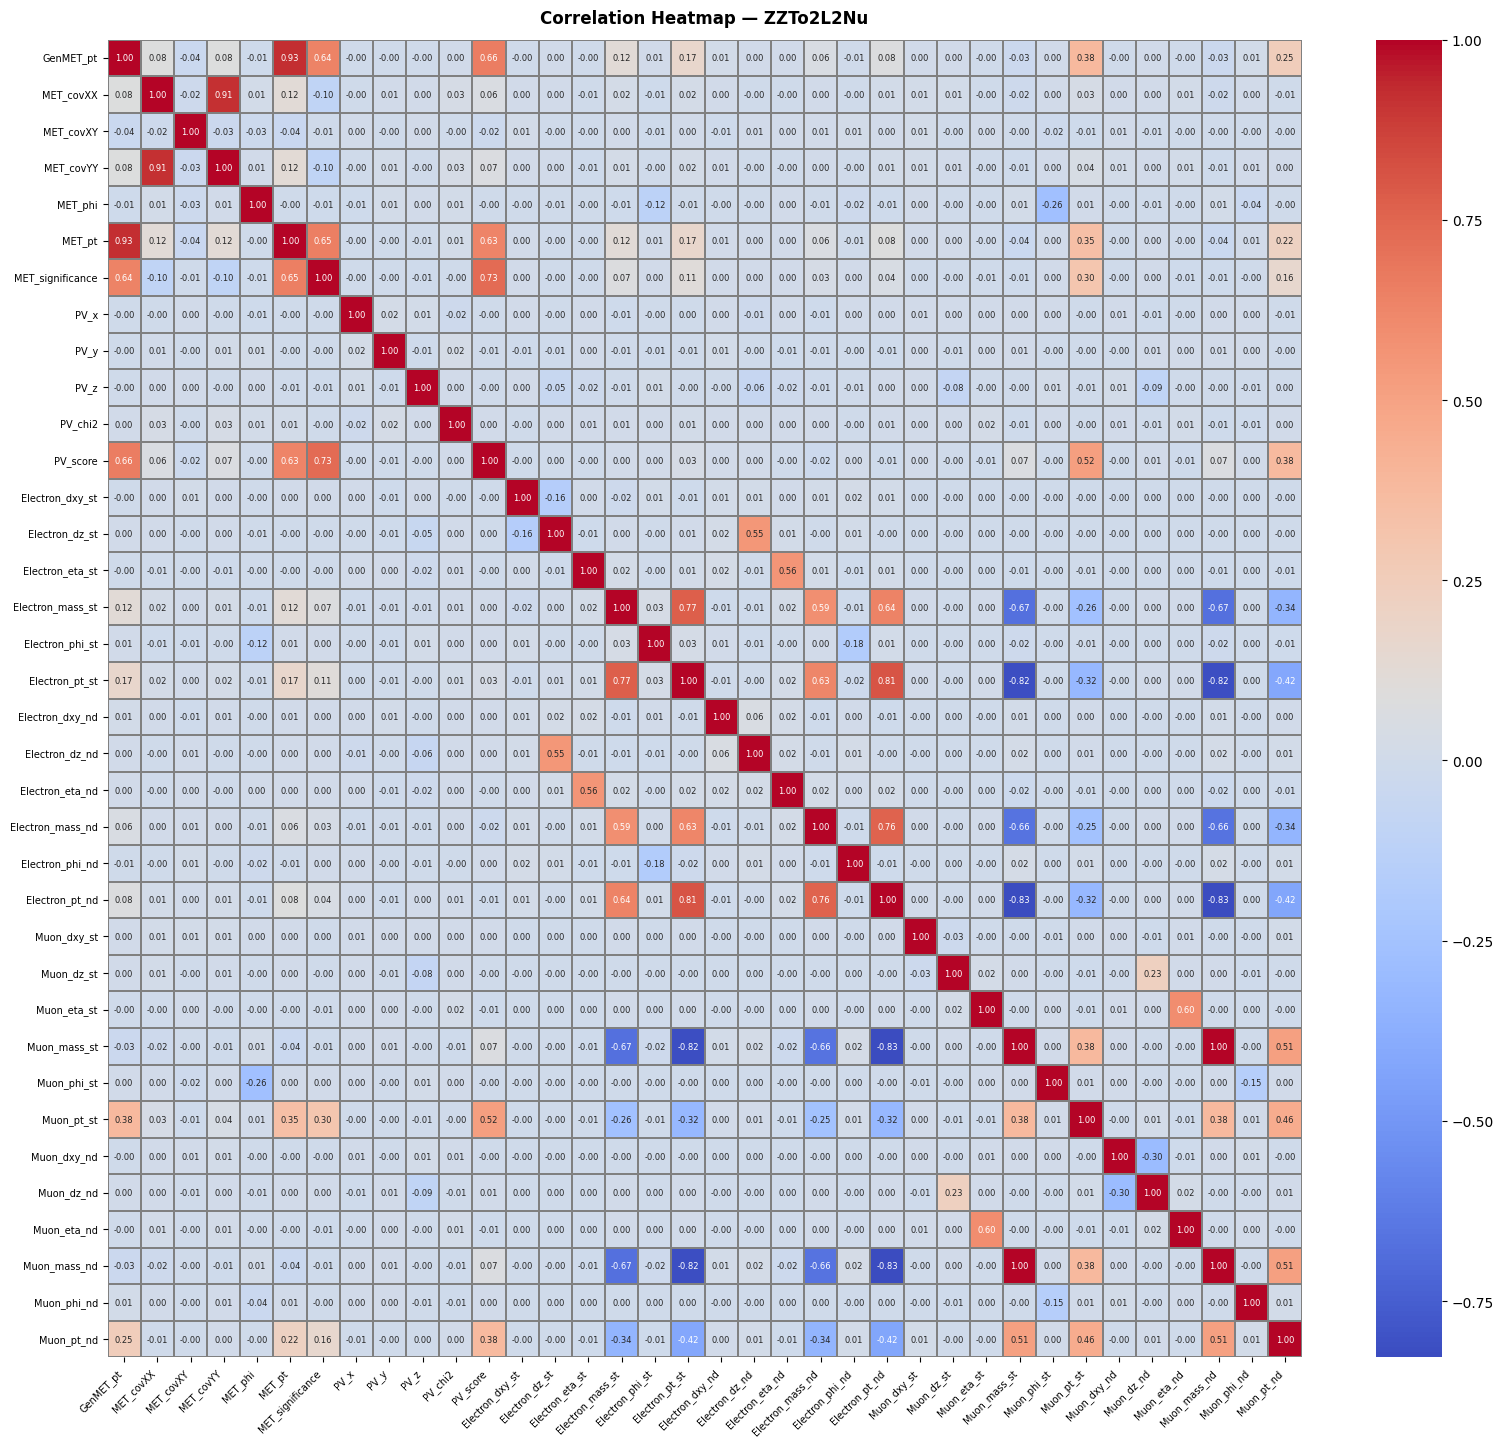

In [49]:
_correlation_heatmap(df, FLOAT_FEATURES_ZZTo2L2Nu, label)

In [50]:
print(df[["GenMET_pt", "MET_pt"]].describe())

          GenMET_pt        MET_pt
count  30324.000000  30324.000000
mean      57.528619     63.183405
std       50.674432     50.879232
min        0.024750      0.364330
25%       25.324219     30.368127
50%       44.375000     50.643513
75%       73.375000     80.757496
max      955.000000    993.224548


Statistics for dataset ZZTo2L2Nu:
    Mean MET_pt: 63.18340508185269, Median MET_pt: 50.64351272583008
    Mean GenMET_pt: 57.52861939261542, Median GenMET_pt: 44.375


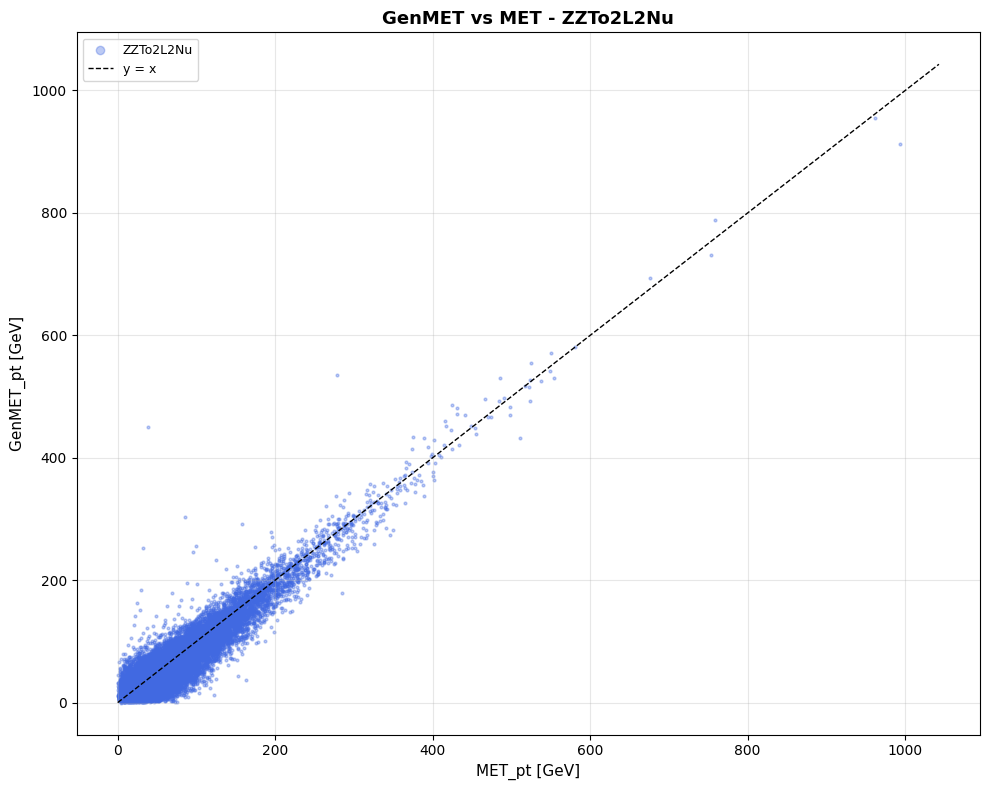

In [51]:
_scatterplot_MET(df, label=label, color=color)

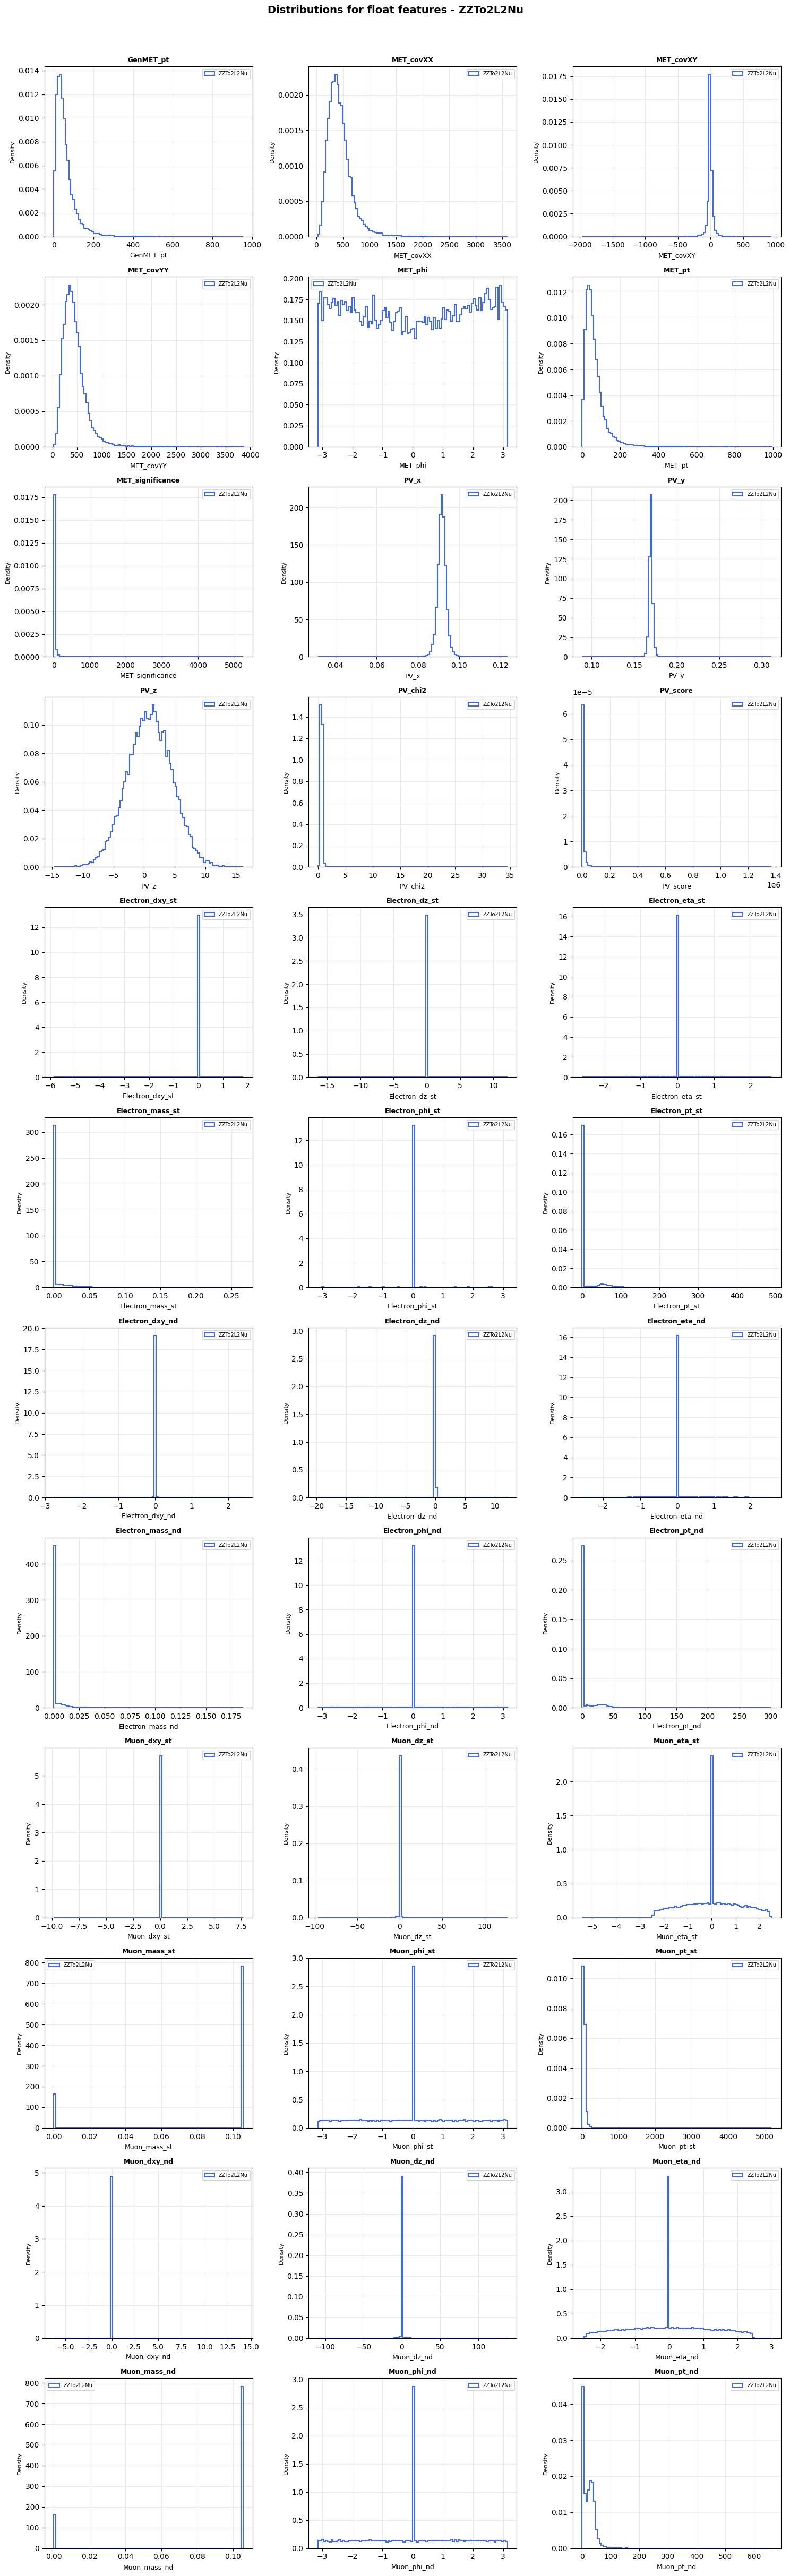

In [52]:
_data_distributions(df, FLOAT_FEATURES_ZZTo2L2Nu, label, color)

In [53]:
print(df[["Electron_mass_st", "Electron_mass_nd",]].describe())

       Electron_mass_st  Electron_mass_nd
count      30324.000000      30324.000000
mean           0.004354          0.001998
std            0.014226          0.006630
min            0.000000          0.000000
25%            0.000000          0.000000
50%            0.000000          0.000000
75%            0.000000          0.000000
max            0.266846          0.186890


In [54]:
print(df[["Muon_mass_st", "Muon_mass_nd",]].describe())

       Muon_mass_st  Muon_mass_nd
count  30324.000000  30324.000000
mean       0.087522      0.087521
std        0.039901      0.039901
min        0.000000      0.000000
25%        0.105713      0.105713
50%        0.105713      0.105713
75%        0.105713      0.105713
max        0.105713      0.105713


In [55]:
print(df[["Electron_pt_st", "Electron_pt_nd",]].describe())

       Electron_pt_st  Electron_pt_nd
count    30324.000000    30324.000000
mean        10.551580        4.838287
std         28.193822       12.813376
min          0.000000        0.000000
25%          0.000000        0.000000
50%          0.000000        0.000000
75%          0.000000        0.000000
max        488.774200      300.891815


In [56]:
print(df[["Muon_pt_st", "Muon_pt_nd",]].describe())

         Muon_pt_st    Muon_pt_nd
count  30324.000000  30324.000000
mean      48.900096     22.224039
std       58.089632     19.893231
min        0.000000      0.000000
25%       12.378085      4.861733
50%       47.531439     21.122346
75%       67.550930     35.066940
max     5188.601074    660.563171


Outliers — ZZTo2L2Nu
  GenMET_pt              1683 outliers (5.55%)
  MET_covXX              1011 outliers (3.33%)
  MET_covXY              3637 outliers (11.99%)
  MET_covYY              1000 outliers (3.30%)
  MET_phi                   0 outliers (0.00%)
  MET_pt                 1516 outliers (5.00%)
  MET_significance       3036 outliers (10.01%)
  PV_x                    880 outliers (2.90%)
  PV_y                    897 outliers (2.96%)
  PV_z                    207 outliers (0.68%)
  PV_chi2                1043 outliers (3.44%)
  PV_score               2976 outliers (9.81%)
  Electron_dxy_st        5218 outliers (17.21%)
  Electron_dz_st         5218 outliers (17.21%)
  Electron_eta_st        5218 outliers (17.21%)
  Electron_mass_st       5218 outliers (17.21%)
  Electron_phi_st        5218 outliers (17.21%)
  Electron_pt_st         5218 outliers (17.21%)
  Electron_dxy_nd        5218 outliers (17.21%)
  Electron_dz_nd         5218 outliers (17.21%)
  Electron_eta_nd        5218

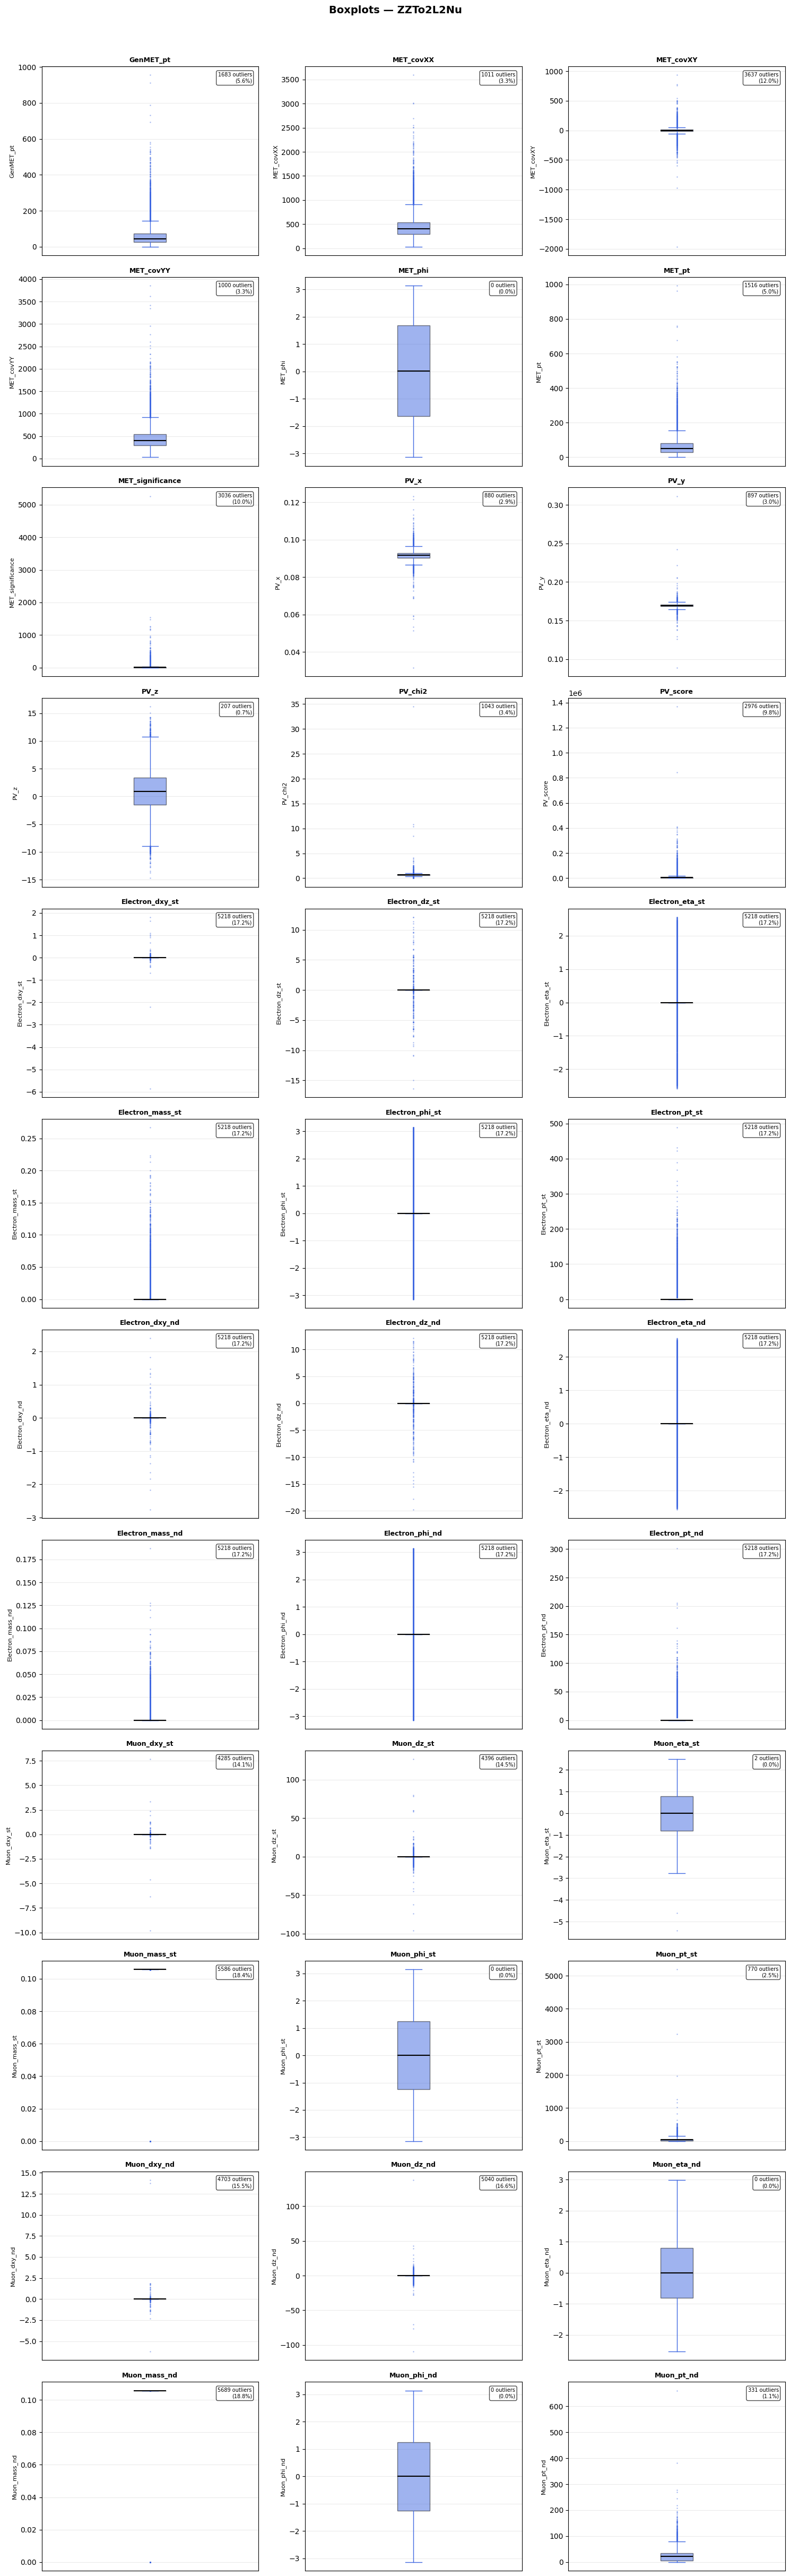

In [57]:
_boxplots(df, FLOAT_FEATURES_ZZTo2L2Nu, label, color)

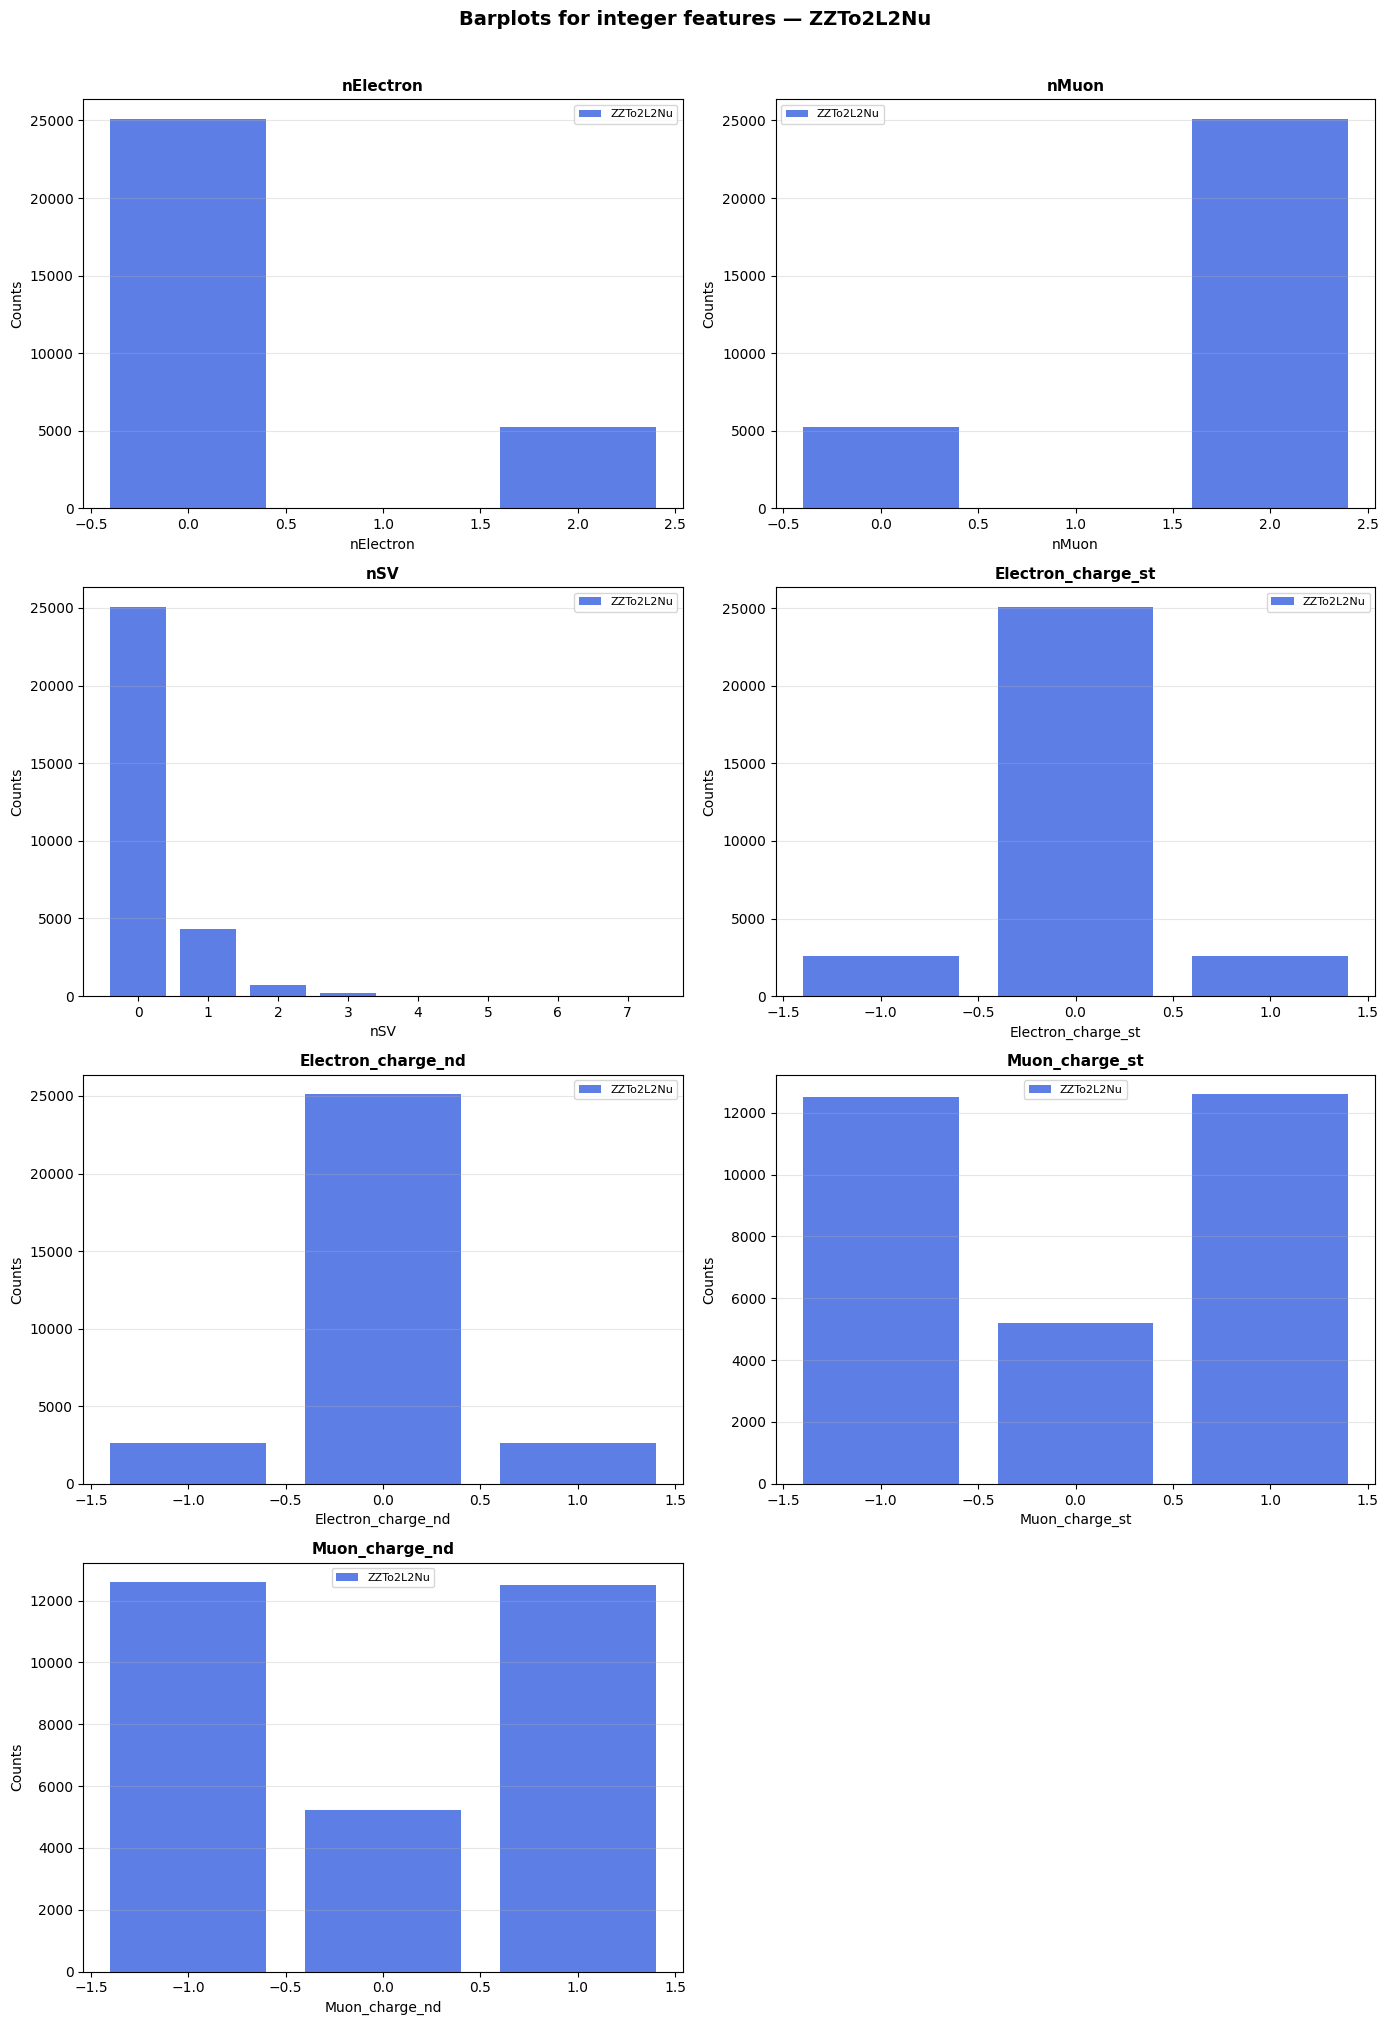

In [58]:
_data_barplots(df, INT_FEATURES_ZZTo2L2Nu, label, color)

In [59]:
print(df["Electron_charge_st"].value_counts())
print(df["Electron_charge_nd"].value_counts())

Electron_charge_st
 0    25106
-1     2615
 1     2603
Name: count, dtype: int64
Electron_charge_nd
 0    25106
 1     2615
-1     2603
Name: count, dtype: int64


In [60]:
print(df["Muon_charge_st"].value_counts())
print(df["Muon_charge_nd"].value_counts())

Muon_charge_st
 1    12599
-1    12507
 0     5218
Name: count, dtype: int64
Muon_charge_nd
-1    12599
 1    12507
 0     5218
Name: count, dtype: int64


As expected, the first and second particles in each pair consistently carry opposite charges, consistent with the Z boson decaying into a particle-antiparticle pair.

Regarding the channel balance, the double electron and double muon channels are not equally represented in the cleaned dataset: the double muon channel contains approximately 25000 events against roughly 5200 in the double electron channel. This imbalance is likely an artifact of the event selection rather than a physical effect, since theory predicts equal branching ratios for the two channels.

Furthermore, to mitigate the effects of the curse of dimensionality, we remove features that are either irrelevant to the analysis or redundant, as identified through the correlation analysis.

In [61]:
DROP_ZZTo2L2Nu = [
    "PV_x", "PV_y",
    "MET_phi", "MET_covYY",
    "Electron_mass_st", "Electron_mass_nd",
    "Muon_mass_st", "Muon_mass_nd"
]

df = df.drop(columns=DROP_ZZTo2L2Nu)
print(f"Shape of ZZTo2L2Nu after preparation: {df.shape[1]} features x {df.shape[0]} events")
print(f"Remaining features of ZZTo2L2Nu after preparation: {list(df.columns)}")

df.to_parquet("../CleanedDatasets/ZZTo2L2Nu.parquet", index=False)

Shape of ZZTo2L2Nu after preparation: 35 features x 30324 events
Remaining features of ZZTo2L2Nu after preparation: ['GenMET_pt', 'MET_covXX', 'MET_covXY', 'MET_pt', 'MET_significance', 'PV_z', 'PV_chi2', 'PV_score', 'Electron_dxy_st', 'Electron_dz_st', 'Electron_eta_st', 'Electron_phi_st', 'Electron_pt_st', 'Electron_dxy_nd', 'Electron_dz_nd', 'Electron_eta_nd', 'Electron_phi_nd', 'Electron_pt_nd', 'Muon_dxy_st', 'Muon_dz_st', 'Muon_eta_st', 'Muon_phi_st', 'Muon_pt_st', 'Muon_dxy_nd', 'Muon_dz_nd', 'Muon_eta_nd', 'Muon_phi_nd', 'Muon_pt_nd', 'nElectron', 'nMuon', 'nSV', 'Electron_charge_st', 'Electron_charge_nd', 'Muon_charge_st', 'Muon_charge_nd']


---

## HToAATo2Mu2B Dataset

The dataset was filtered to retain only events consistent with the expected signal signature. The following selection criteria were applied:

- `MET_pt` ≥ 0, to remove non-physical events with negative Missing Transverse Energy;
- `nMuon` ≥ 2 and `nJet` ≥ 2, to ensure the presence of at least two muons and two jets, as required by the decay chain;
- both leading jets must satisfy a b-tagging score above 0.5 (DeepFlavour), to select jets consistent with b-quark hadronisation;
- positive transverse momenta for both selected muons and jets.

Jet and muon properties were extracted from the leading objects only: for jets, the two candidates with the highest b-tag score were selected; for muons, the first and second entries were taken directly. The best secondary vertex was identified as the one with the highest decay length significance (`SV_dlenSig`).

In addition to the raw features, several engineered variables were computed to provide the model with higher level information:
- invariant masses of the dual muon system (`M_mumu`), the dual jet system (`M_bb`), and the full four-body system (`M_mumu_bb`);
- angular separation between the MET direction and the bb system (`dR_MET_bb`);
- MET projections parallel and perpendicular to the bb axis (`MET_projection_par`, `MET_projection_perp`);
- azimuthal separations between MET and the leading muon and jet (`dPhi_MET_mu1`, `dPhi_MET_jet1`);
- scalar sum of all jet transverse momenta (`HT`).

In [62]:
label = "HToAATo2Mu2B"
entry = DATASETS[label]

FLOAT_FEATURES_HToAATo2Mu2B = entry["float_features"]
INT_FEATURES_HToAATo2Mu2B = entry["int_features"]
color = PALETTE[1]

df = _load_dataset(FLOAT_FEATURES_HToAATo2Mu2B, INT_FEATURES_HToAATo2Mu2B, entry["path"], TREE_NAME)
print(f"Dataset {label}:")
print(f"    {df.shape[1]} features x {df.shape[0]} events")
print(f"    Number of float features: {len(FLOAT_FEATURES_HToAATo2Mu2B)}")
print(f"    Number of int features:   {len(INT_FEATURES_HToAATo2Mu2B)}")

Dataset HToAATo2Mu2B:
    66 features x 2334 events
    Number of float features: 60
    Number of int features:   6



Couples of features with correlation > 0.70:
MET_covYY, MET_covXX = 0.90
MET_significance, MET_pt = 0.78
fixedGridRhoFastjetAll, MET_covXX = 0.79
fixedGridRhoFastjetAll, MET_covYY = 0.79
Jet_mass_bst, Jet_pt_bst = 0.88
Jet_mass_bnd, Jet_pt_bnd = 0.88
Muon_eta_nd, Muon_eta_st = 0.73


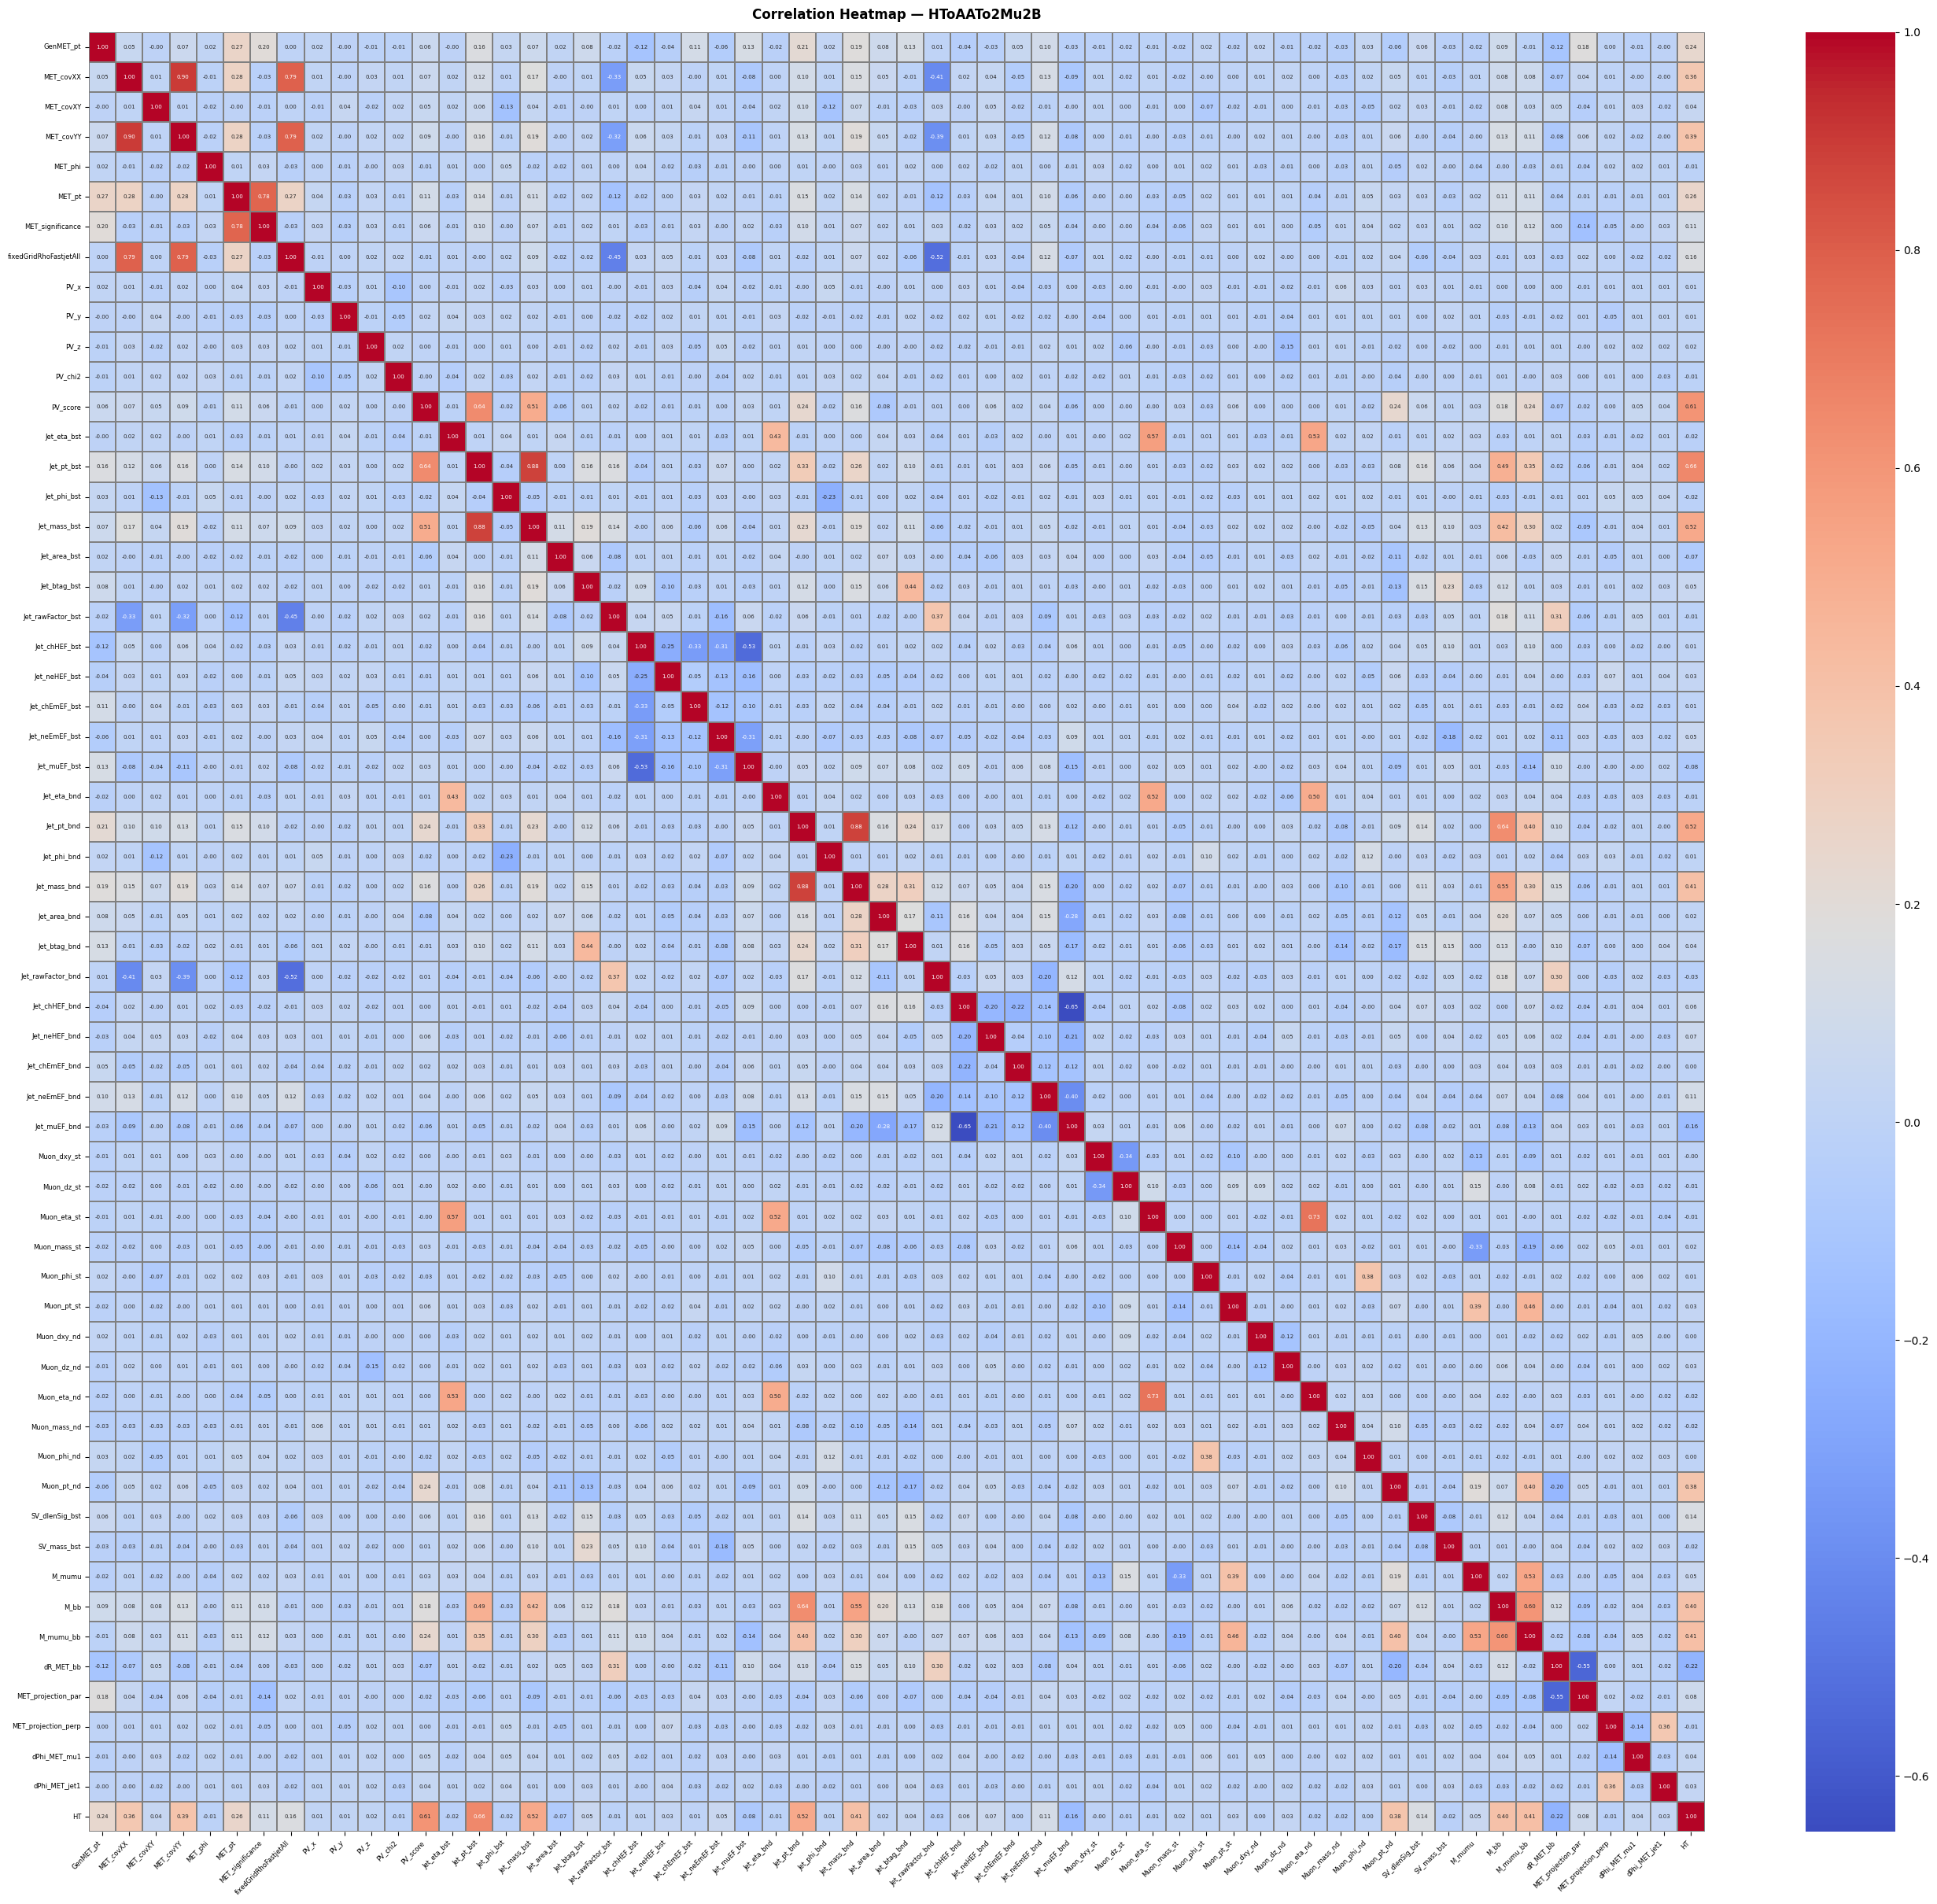

In [63]:
_correlation_heatmap(df, FLOAT_FEATURES_HToAATo2Mu2B, label)

In [64]:
print(df[["GenMET_pt", "MET_pt"]].describe())

          GenMET_pt       MET_pt
count  2.334000e+03  2334.000000
mean   8.424845e+00    28.685803
std    9.108244e+00    17.989763
min    2.030376e-12     0.424678
25%    2.197266e+00    15.695955
50%    6.013672e+00    25.229407
75%    1.168555e+01    38.216170
max    1.122500e+02   248.739197


Statistics for dataset HToAATo2Mu2B:
    Mean MET_pt: 28.68580299906988, Median MET_pt: 25.22940731048584
    Mean GenMET_pt: 8.424845320365156, Median GenMET_pt: 6.013671875


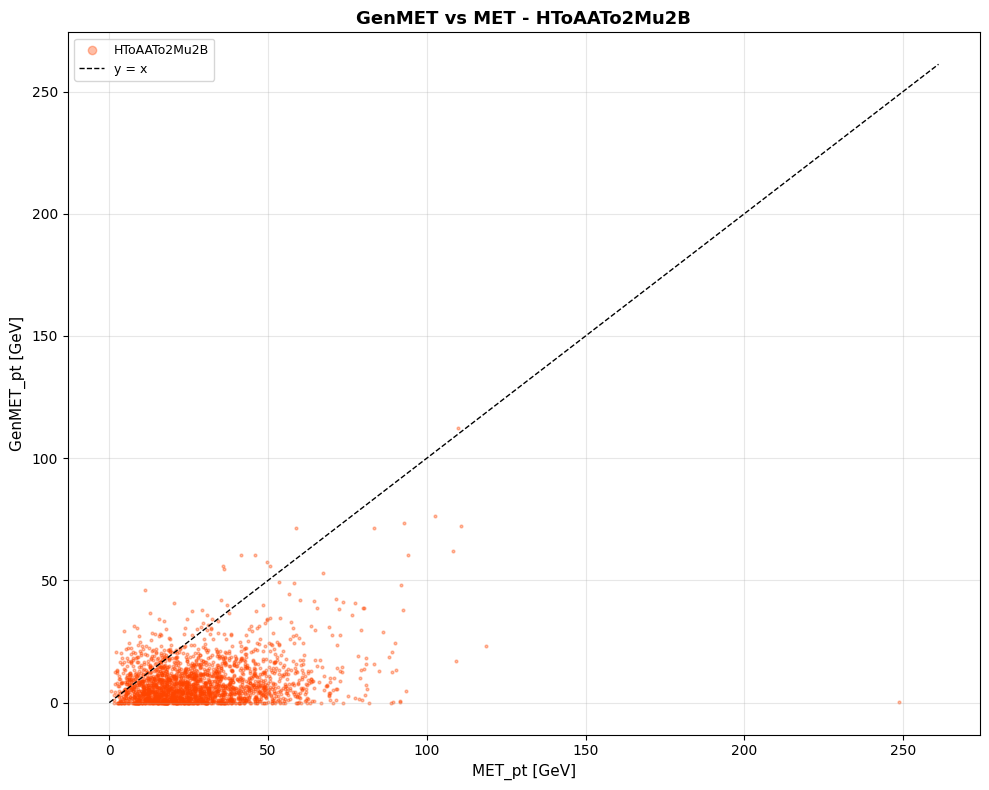

In [65]:
_scatterplot_MET(df, label, color)

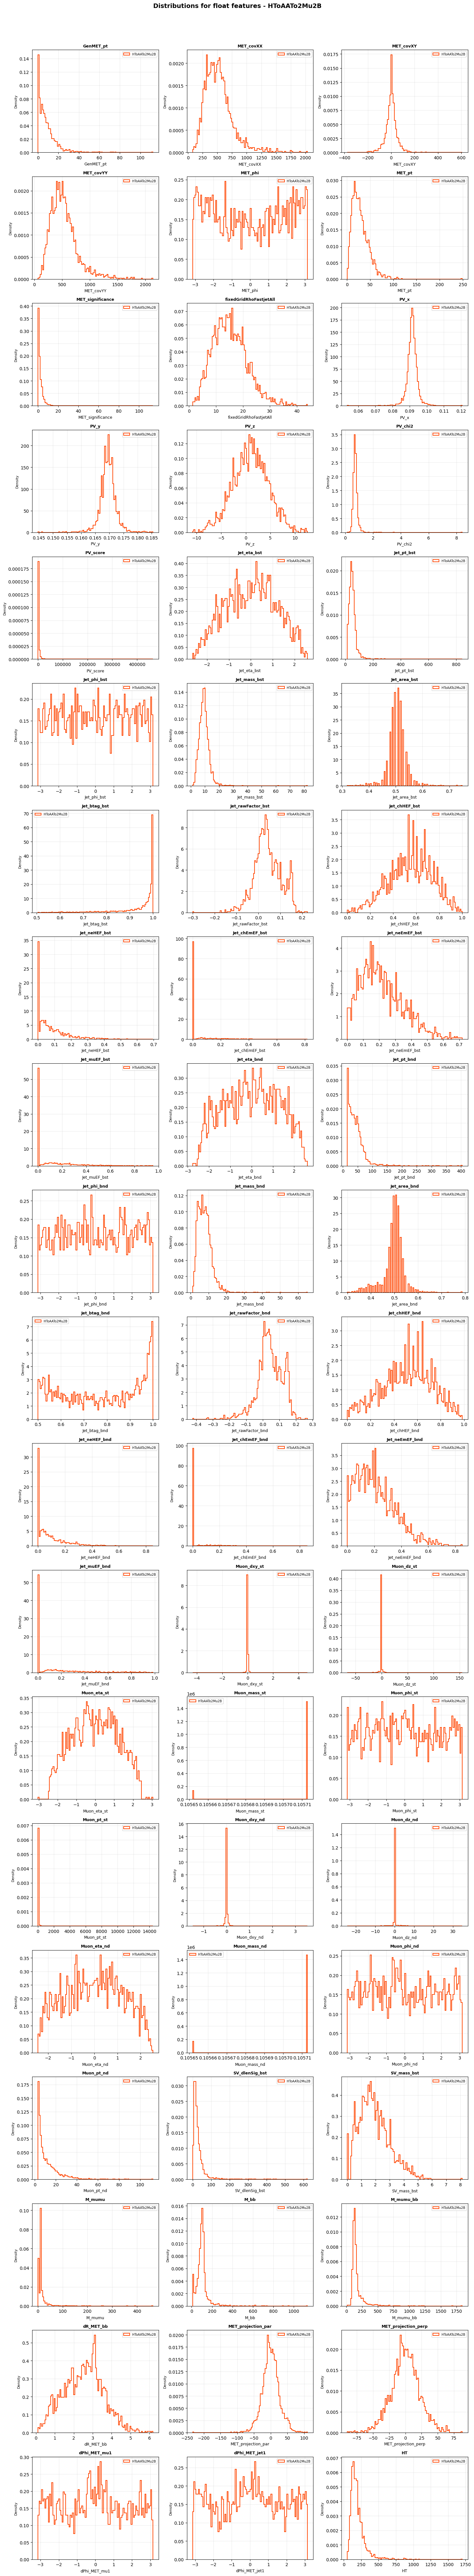

In [66]:
_data_distributions(df, FLOAT_FEATURES_HToAATo2Mu2B, label, color)

In [67]:
print(df[["Muon_mass_st", "Muon_mass_nd",]].describe())

       Muon_mass_st  Muon_mass_nd
count   2334.000000   2334.000000
mean       0.105708      0.105707
std        0.000017      0.000019
min        0.105652      0.105652
25%        0.105713      0.105713
50%        0.105713      0.105713
75%        0.105713      0.105713
max        0.105713      0.105713


In [68]:
print(df[["Jet_mass_bst", "Jet_mass_bnd",]].describe())

       Jet_mass_bst  Jet_mass_bnd
count   2334.000000   2334.000000
mean       9.436213      7.842969
std        3.787840      4.143507
min        1.336914      1.108398
25%        7.225586      4.972656
50%        9.203125      7.367188
75%       11.132812      9.851562
max       82.375000     65.312500


In [69]:
print(df[["Muon_pt_st", "Muon_pt_nd",]].describe())

         Muon_pt_st   Muon_pt_nd
count   2334.000000  2334.000000
mean      41.023310    11.551438
std      336.044131    10.394876
min        3.172570     3.005699
25%        9.105308     4.517785
50%       18.902659     7.692247
75%       39.128160    15.155298
max    14438.080078   112.168785


In [70]:
print(df[["Jet_pt_bst", "Jet_pt_bnd",]].describe())

        Jet_pt_bst   Jet_pt_bnd
count  2334.000000  2334.000000
mean     53.486136    43.858562
std      34.153863    32.493352
min      15.015625    15.015625
25%      37.031250    24.292969
50%      48.750000    37.812500
75%      62.312500    53.593750
max     843.000000   403.750000


In [71]:
print(df[["M_mumu"]].describe())

            M_mumu
count  2334.000000
mean     15.671193
std      25.779699
min       0.231856
25%       7.257634
50%      11.946803
75%      13.233748
max     464.256958


Outliers — HToAATo2Mu2B
  GenMET_pt               101 outliers (4.33%)
  MET_covXX                77 outliers (3.30%)
  MET_covXY               176 outliers (7.54%)
  MET_covYY                91 outliers (3.90%)
  MET_phi                   0 outliers (0.00%)
  MET_pt                   52 outliers (2.23%)
  MET_significance        129 outliers (5.53%)
  fixedGridRhoFastjetAll     25 outliers (1.07%)
  PV_x                    127 outliers (5.44%)
  PV_y                    107 outliers (4.58%)
  PV_z                     17 outliers (0.73%)
  PV_chi2                 105 outliers (4.50%)
  PV_score                170 outliers (7.28%)
  Jet_eta_bst               0 outliers (0.00%)
  Jet_pt_bst              104 outliers (4.46%)
  Jet_phi_bst               0 outliers (0.00%)
  Jet_mass_bst             49 outliers (2.10%)
  Jet_area_bst            150 outliers (6.43%)
  Jet_btag_bst            269 outliers (11.53%)
  Jet_rawFactor_bst        23 outliers (0.99%)
  Jet_chHEF_bst             3 out

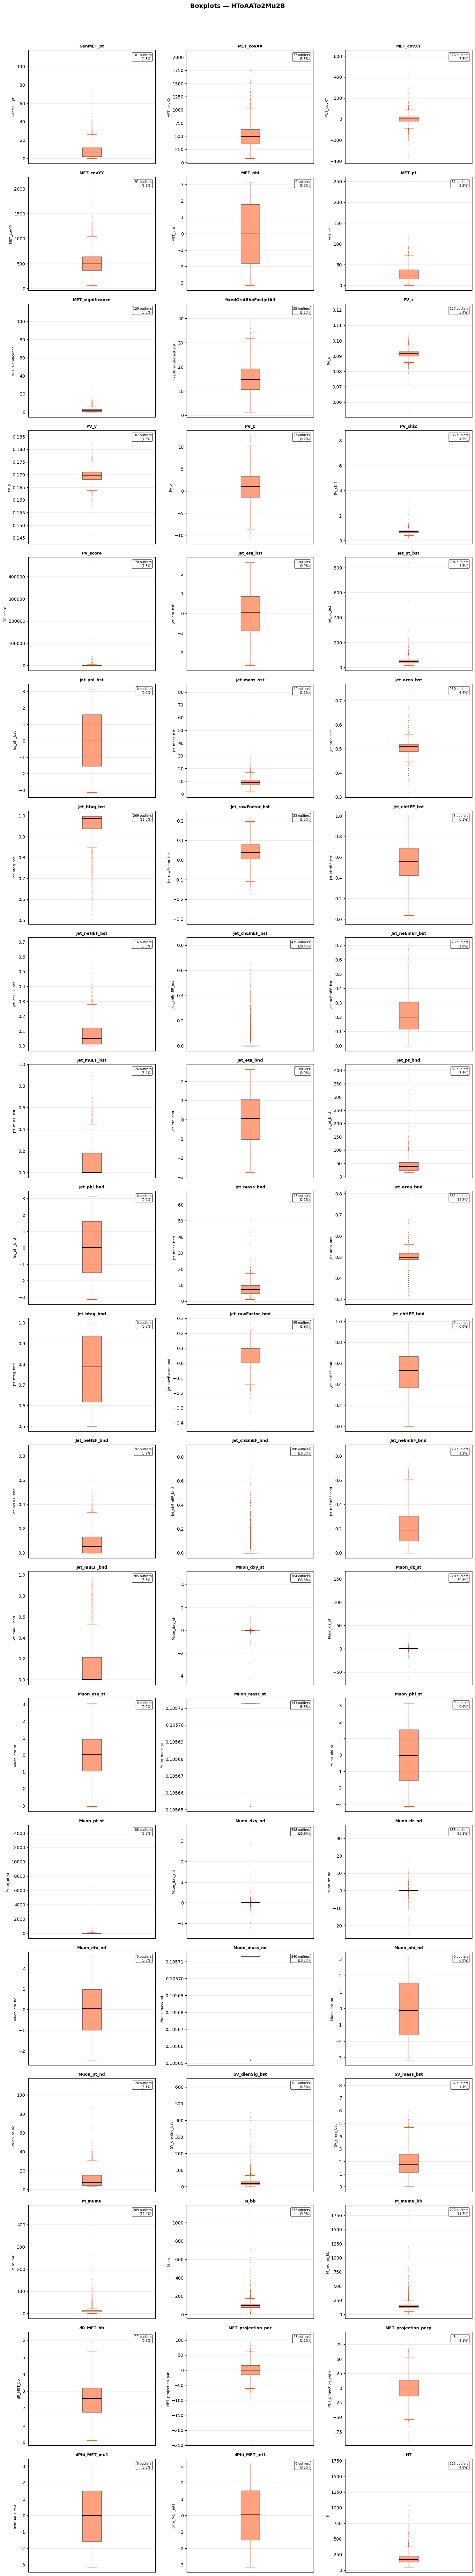

In [72]:
_boxplots(df, FLOAT_FEATURES_HToAATo2Mu2B, label, color)

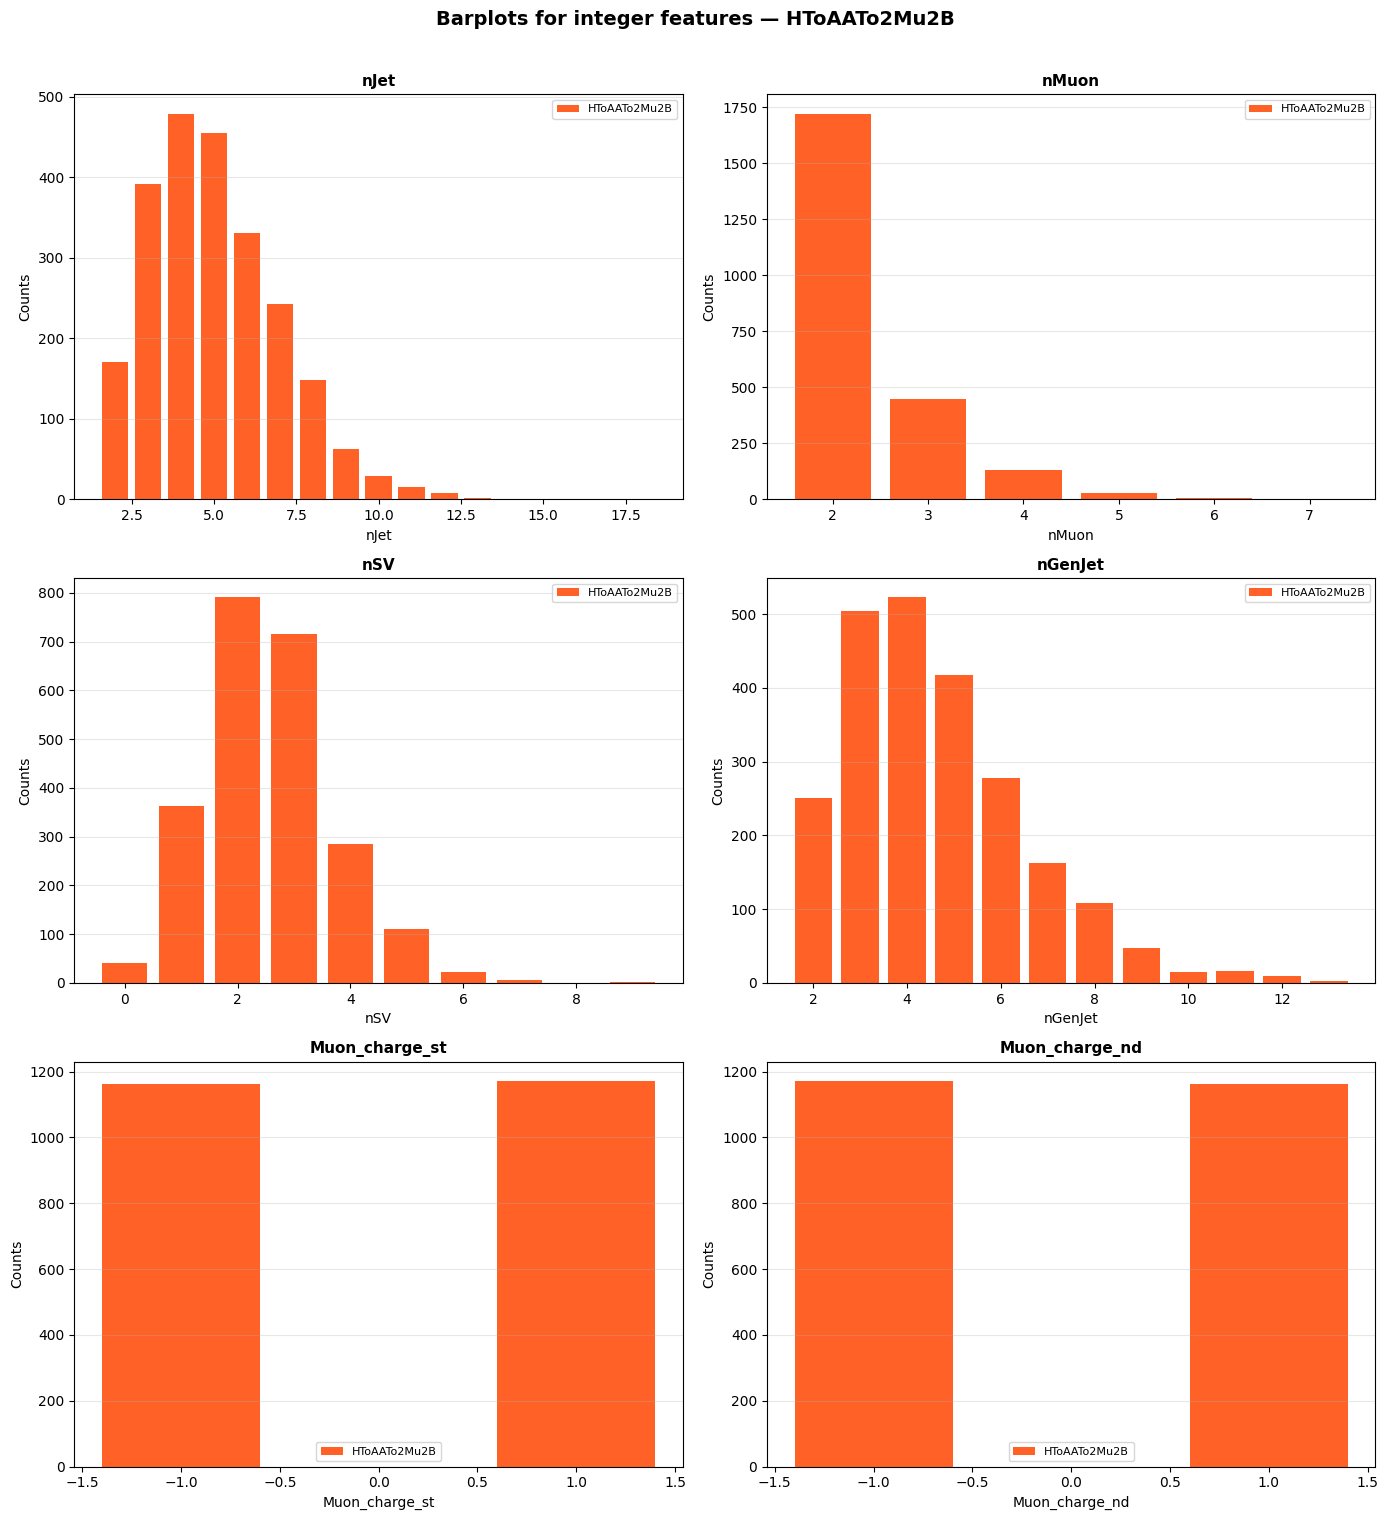

In [73]:
_data_barplots(df, INT_FEATURES_HToAATo2Mu2B, label, color)

In [74]:
print(df["Muon_charge_st"].value_counts())
print(df["Muon_charge_nd"].value_counts())

Muon_charge_st
 1    1172
-1    1162
Name: count, dtype: int64
Muon_charge_nd
-1    1172
 1    1162
Name: count, dtype: int64


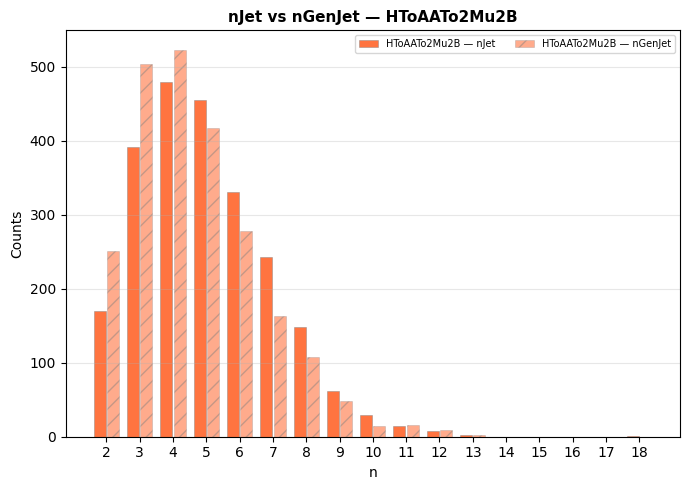

In [75]:
_nJet_vs_nGenJet(df, label, color)

Again, at this point we remove feature that we consider either irrelevant or redundant for the purpose of our model.

In [76]:
DROP_HToAATo2Mu2B = [
    "nGenJet",
    "PV_x", "PV_y",
    "MET_phi", "MET_covYY",
    "Muon_mass_st", "Muon_mass_nd",
    "Jet_mass_bst", "Jet_mass_bnd",
    "Jet_chEmEF_bst", "Jet_chEmEF_bnd",
    "Jet_neEmEF_bst", "Jet_neEmEF_bnd",
    "Jet_muEF_bst", "Jet_muEF_bnd",
    "Jet_pt_bst", "Jet_pt_bnd",
    "Jet_area_bst", "Jet_area_bnd",
    "Muon_dxy_st", "Muon_dxy_nd",
    "Muon_dz_st", "Muon_dz_nd"
]

df = df.drop(columns=DROP_HToAATo2Mu2B)
print(f"Shape of HToAATo2Mu2B after preparation: {df.shape[1]} features x {df.shape[0]} events")
print(f"Remaining features of HToAATo2Mu2B after preparation: {list(df.columns)}")

df.to_parquet("../CleanedDatasets/HToAATo2Mu2B.parquet", index=False)

Shape of HToAATo2Mu2B after preparation: 43 features x 2334 events
Remaining features of HToAATo2Mu2B after preparation: ['GenMET_pt', 'MET_covXX', 'MET_covXY', 'MET_pt', 'MET_significance', 'fixedGridRhoFastjetAll', 'PV_z', 'PV_chi2', 'PV_score', 'Jet_eta_bst', 'Jet_phi_bst', 'Jet_btag_bst', 'Jet_rawFactor_bst', 'Jet_chHEF_bst', 'Jet_neHEF_bst', 'Jet_eta_bnd', 'Jet_phi_bnd', 'Jet_btag_bnd', 'Jet_rawFactor_bnd', 'Jet_chHEF_bnd', 'Jet_neHEF_bnd', 'Muon_eta_st', 'Muon_phi_st', 'Muon_pt_st', 'Muon_eta_nd', 'Muon_phi_nd', 'Muon_pt_nd', 'SV_dlenSig_bst', 'SV_mass_bst', 'M_mumu', 'M_bb', 'M_mumu_bb', 'dR_MET_bb', 'MET_projection_par', 'MET_projection_perp', 'dPhi_MET_mu1', 'dPhi_MET_jet1', 'HT', 'nJet', 'nMuon', 'nSV', 'Muon_charge_st', 'Muon_charge_nd']
